In [1]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 25.5 MB/s eta 0:00:00


In [2]:
! pip install shap

In [3]:
import os
import urllib.request
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from rdkit import Chem
from rdkit.Chem import Draw

import shap

urls = {
    "ace_eda_final.csv" : "https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/data/ace_eda_final.csv",
    "features.py" : "https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/src/features.py",
    "X_train_scaf_rus.npy" : "https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/data/X_train_scaf_rus.npy",
    "xgb_tuned_model.pkl" : "https://github.com/daniellaeme/ACE-Inhibitor-QSAR/blob/main/models/xgb_tuned_model.pkl?raw=true"
}

for filename, url in urls.items():
    if os.path.exists(filename):
        os.remove(filename)
    urllib.request.urlretrieve(url, filename)
    print(f"Downloaded: {filename}")

sys.path.append('.')

import features

print("\nSuccess! All modules imported and ready to go.")

Downloaded: ace_eda_final.csv
Downloaded: features.py
Downloaded: X_train_scaf_rus.npy
Downloaded: xgb_tuned_model.pkl

Success! All modules imported and ready to go.


In [4]:
xgb_tuned = joblib.load('xgb_tuned_model.pkl')

X_train_scaf_rus = np.load('X_train_scaf_rus.npy')

feature_names = [f'Bit_{i}' for i in range(2048)]
feature_names[:5]

['Bit_0', 'Bit_1', 'Bit_2', 'Bit_3', 'Bit_4']

# Global Importance (Summary Plot)

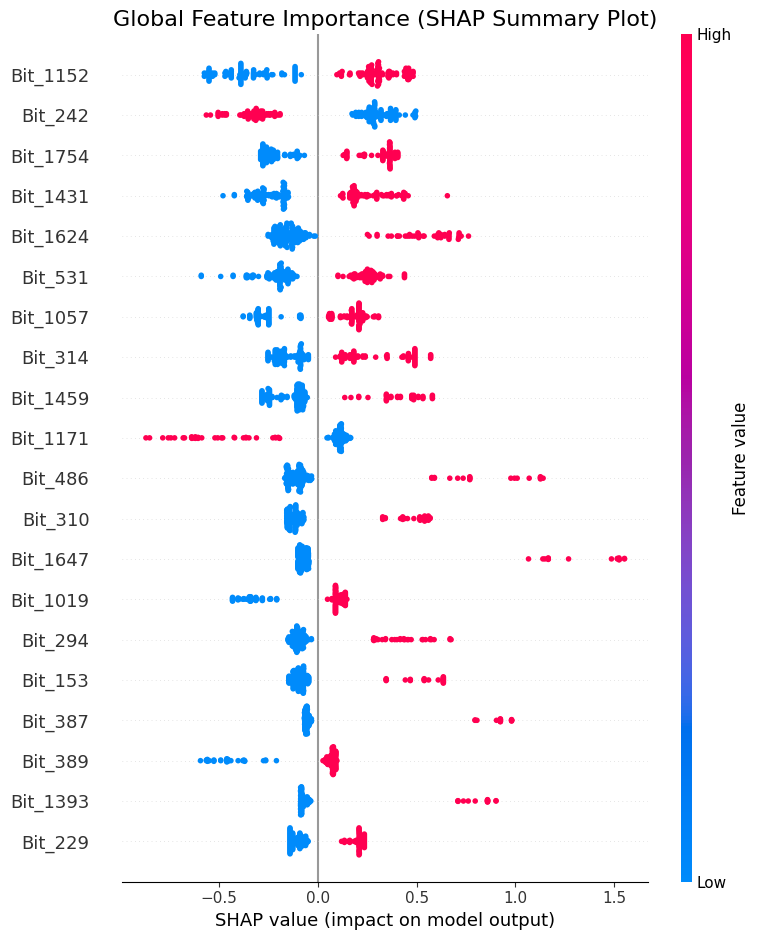

In [5]:
explainer = shap.TreeExplainer(xgb_tuned)

shap_values = explainer.shap_values(X_train_scaf_rus)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_scaf_rus, feature_names=feature_names, show=False)
plt.title("Global Feature Importance (SHAP Summary Plot)", fontsize=16)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300)
plt.show()

# Chemical Mapping

Found Bit 1152 in SMILES: C=C1N[C@@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H]([C@@H](C)CC)C(=O)N[C@@H](Cc2c[nH]cn2)C(=O)N[C@H](C(=O)N[C@@H](C)C(N)=O)CSCCC(=O)N2CN3CN(C2)C(=O)CCSC[C@H](NC(=O)[C@H](Cc2c[nH]cn2)NC(=O)[C@@H](CO)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](C(C)(C)C)NC(=O)[C@@H](NC(=O)[C@H](C)N)CSCCC3=O)C(=O)N[C@@H](CO)C(=O)N[C@@H](CO)C(=O)N[C@H]1CC(C)C


[16:28:51] DEPRECATION WARNING: please use MorganGenerator


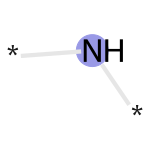

In [6]:
top_bit = 1152

df = pd.read_csv('ace_eda_final.csv')

bit_img = features.visualise_morgan_bit(df['canonical_smiles'].tolist(), top_bit)
bit_img